<h1 style="color:darkblue;">BULIDING THE MODELS WTH DIFFERENT TECHNIQUES</h1>

In [45]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV,cross_val_score
import ipywidgets as widgets
from ipywidgets import interact
import pickle
import os


In [54]:
!git clone -b localbranch https://github.com/kalasamuel/CompanyBankruptcyML.git

Cloning into 'CompanyBankruptcyML'...
remote: Enumerating objects: 240, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 240 (delta 9), reused 8 (delta 3), pack-reused 220 (from 1)
Receiving objects: 100% (240/240), 54.41 MiB | 24.05 MiB/s, done.
Resolving deltas: 100% (123/123), done.


In [55]:
%cd CompanyBankruptcyML

/content/CompanyBankruptcyML


In [69]:
!ls

bankruptcy_prediction_binaryclassification.ipynb  loaddata.ipynb
bankruptcy_prediction_multi_clasiification.ipynb  models
data						  README.md
Data_dictionary.txt				  requirements.txt
EDA.ipynb					  ug_dataset.ipynb
ExplainableAI.ipynb


In [70]:
!git config --global user.email "kalasamuel79@gmail.com"
!git config --global user.name "kalasamuel"

In [71]:
!git add .

In [72]:
!git commit -m "added trained XGBoost model"

[localbranch af82b61] added trained XGBoost model
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 models/model_xgb.pkl


In [74]:
!git push

fatal: could not read Username for 'https://github.com': No such device or address


In [58]:
poland_df = pd.read_csv("data/poland_df.csv")
poland_df.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt_class,bankrupt_after_years
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,0
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,0
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,0
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,0
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,0


<h1 style="color:darkblue;">Addressing The Class Balance Issue</h1>

In [59]:
#splitting the Data
X = poland_df.drop(columns=["bankrupt_class","bankrupt_after_years"])
y = poland_df["bankrupt_after_years"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

<h1 style="color:darkblue;">The Oversampling Technique</h1>

In [60]:
# Applying Random Oversampler on training data only
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

#Checking for the escence of OverSampling
y_train_over.value_counts(normalize=True).sort_index()

,proportion
bankrupt_after_years,
0,0.166667
1,0.166667
2,0.166667
3,0.166667
4,0.166667
5,0.166667


<h1 style="color:darkblue";>Ensemble Methods </h1>
<p>Ensemble Methods work by building multiple models on random subsets of the same data,compare predictionsand make final predictions</p>

<h2 style="color:darkblue";>The Random Forest Classifier </h2>

In [ ]:
# A classifier that uses random forest
classifier = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(random_state=42)
)

# Cross Validation
cross_val_scores = cross_val_score(classifier,X_train_over,y_train_over,cv=5, scoring="roc_auc_ovr",n_jobs=-1)

<h2 style="color:darkblue";>Hyperparameter Tuning</h2>

In [ ]:
params_rf = {
    "randomforestclassifier__n_estimators": [100],
    "randomforestclassifier__max_depth": range(5, 21),
    "randomforestclassifier__max_features": ["sqrt"],
    "simpleimputer__strategy": ["mean", "median"]
}
params_rf

{'randomforestclassifier__n_estimators': [100],
 'randomforestclassifier__max_depth': range(5, 21),
 'randomforestclassifier__max_features': ['sqrt'],
 'simpleimputer__strategy': ['mean', 'median']}

<h2 style="color:darkblue";>The GridSearchCV</h2>

In [ ]:
model_rf = GridSearchCV(
    classifier,
    param_grid=params_rf,
    cv=5,
    scoring="roc_auc_ovr",
    n_jobs=-1,
    verbose=1
)
model_rf.fit(X_train_over,y_train_over)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': range(5, 21), 'randomforestclassifier__max_features': ['sqrt'], 'randomforestclassifier__n_estimators': [100], 'simpleimputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc_ovr'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the 

In [ ]:
results = model_rf.cv_results_
cv_results = pd.DataFrame(results)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__max_features,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,13.615161,2.249158,0.241283,0.012044,5,sqrt,100,mean,"{'randomforestclassifier__max_depth': 5, 'rand...",0.815091,0.821412,0.818133,0.819981,0.819106,0.818745,0.002121,31
1,14.590503,0.865227,0.356427,0.179196,5,sqrt,100,median,"{'randomforestclassifier__max_depth': 5, 'rand...",0.810228,0.814434,0.810673,0.814093,0.813326,0.812551,0.001758,32
2,15.579326,1.369827,0.274714,0.019813,6,sqrt,100,mean,"{'randomforestclassifier__max_depth': 6, 'rand...",0.874870,0.880806,0.877084,0.881537,0.878041,0.878468,0.002446,29
3,16.807071,1.159603,0.315416,0.096030,6,sqrt,100,median,"{'randomforestclassifier__max_depth': 6, 'rand...",0.872760,0.877040,0.872635,0.874817,0.872322,0.873915,0.001794,30
4,17.783371,1.350464,0.318412,0.081697,7,sqrt,100,mean,"{'randomforestclassifier__max_depth': 7, 'rand...",0.929341,0.932649,0.929491,0.932793,0.928773,0.930609,0.001741,27


<h2 style="color:darkblue";>Extracting The Best Parameters</h2>

In [ ]:
best_params_rf = model_rf.best_params_
best_score_rf = model_rf.best_score_
best_model_rf = model_rf.best_estimator_


print("Best Model:", best_model_rf)
print("Best params:", best_params_rf)
print("Best Score:", best_score_rf)

Best Model: Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=20, random_state=42))])
Best params: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__n_estimators': 100, 'simpleimputer__strategy': 'median'}
Best Score: 0.9999879678508524


<h2 style="color:darkblue";>Classification Report</h2>

In [ ]:
report_rf = classification_report(y_test,model_rf.predict(X_test))
print(report_rf)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      8263
           1       0.20      0.04      0.06        82
           2       0.07      0.01      0.02       103
           3       0.00      0.00      0.00        99
           4       0.00      0.00      0.00        80
           5       0.17      0.04      0.06        54

    accuracy                           0.95      8681
   macro avg       0.23      0.18      0.19      8681
weighted avg       0.91      0.95      0.93      8681



<h2 style="color:darkblue";>The Confusion Matrix </h2>

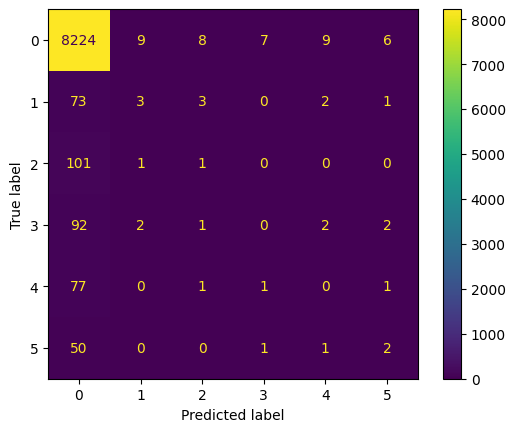

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_rf,X_test,y_test);

<h2 style="color:darkblue";>Feature Importance</h2>

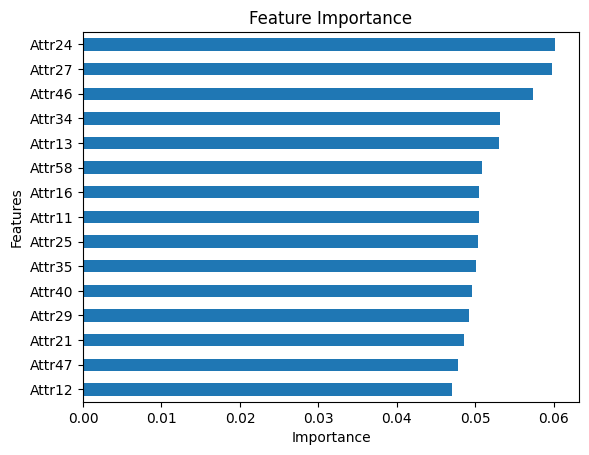

In [ ]:
best_model_rf = model_rf.best_estimator_

importances = best_model_rf.named_steps["randomforestclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp.tail(15).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

<h2 style="color:darkblue";> GRADIENT BOOSTING TREES</h2>
<p>Fitting multiple models in sequence using all the training data</p>


In [ ]:
# A classifier that uses random forest
clf = make_pipeline(
    SimpleImputer(),
    GradientBoostingClassifier(random_state=42)
)

# Cross Validation
cross_val_scores = cross_val_score(clf,X_train_over,y_train_over,cv=5,scoring="roc_auc_ovr",n_jobs=-1)

<h2 style="color:darkblue";>Hyperparameter Tuning</h2>

In [ ]:
params_boost = {
    "simpleimputer__strategy": ["mean", "median"],
    "gradientboostingclassifier__n_estimators": [100],
    "gradientboostingclassifier__max_depth": range(2, 6),
    "gradientboostingclassifier__learning_rate": [0.01, 0.05, 0.1],
}
params_boost

{'simpleimputer__strategy': ['mean', 'median'],
 'gradientboostingclassifier__n_estimators': [100],
 'gradientboostingclassifier__max_depth': range(2, 6),
 'gradientboostingclassifier__learning_rate': [0.01, 0.05, 0.1]}

In [ ]:
model_boost = GridSearchCV(
    clf,
    param_grid=params_boost,
    cv=5,
    scoring="roc_auc_ovr",
    n_jobs=-1,
    verbose=1
)
model_boost.fit(X_train_over,y_train_over)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gradientboostingclassifier__learning_rate': [0.01, 0.05, ...], 'gradientboostingclassifier__max_depth': range(2, 6), 'gradientboostingclassifier__n_estimators': [100], 'simpleimputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc_ovr'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControl

In [ ]:
results_boost = model_boost.cv_results_
cv_results_boost = pd.DataFrame(results_boost)
cv_results_boost.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gradientboostingclassifier__learning_rate,param_gradientboostingclassifier__max_depth,param_gradientboostingclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,347.899812,91.542371,0.606145,0.354096,0.01,2,100,mean,{'gradientboostingclassifier__learning_rate': ...,0.739761,0.740217,0.741126,0.743284,0.741237,0.741125,0.001213,23
1,445.769828,108.661121,0.608147,0.237093,0.01,2,100,median,{'gradientboostingclassifier__learning_rate': ...,0.731031,0.733339,0.730534,0.731981,0.729045,0.731186,0.001435,24
2,286.635287,1.776825,0.415177,0.005401,0.01,3,100,mean,{'gradientboostingclassifier__learning_rate': ...,0.802811,0.804307,0.804447,0.806421,0.803588,0.804315,0.001204,21
3,325.135109,18.480453,0.450830,0.037018,0.01,3,100,median,{'gradientboostingclassifier__learning_rate': ...,0.795955,0.797439,0.797798,0.796349,0.795448,0.796598,0.000888,22
4,446.235067,26.302097,0.598936,0.123117,0.01,4,100,mean,{'gradientboostingclassifier__learning_rate': ...,0.853411,0.856613,0.855617,0.857039,0.855098,0.855556,0.001275,17


In [ ]:
best_params_boost = model_boost.best_params_
best_score_boost = model_boost.best_score_
best_model_boost = model_boost.best_estimator_


print("Best Model:", best_model_boost)
print("Best params:", best_params_boost)
print("Best Score:", best_score_boost)

Best Model: Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(max_depth=5, random_state=42))])
Best params: {'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__max_depth': 5, 'gradientboostingclassifier__n_estimators': 100, 'simpleimputer__strategy': 'mean'}
Best Score: 0.9986777517244845


<h2 style="color:darkblue";>The Classification Report</h2>

In [ ]:
report_boost = classification_report(y_test,model_boost.predict(X_test) )
print(report_boost)

              precision    recall  f1-score   support

           0       0.99      0.91      0.95      8263
           1       0.08      0.27      0.13        82
           2       0.05      0.12      0.07       103
           3       0.05      0.14      0.08        99
           4       0.07      0.15      0.10        80
           5       0.17      0.35      0.22        54

    accuracy                           0.88      8681
   macro avg       0.24      0.32      0.26      8681
weighted avg       0.94      0.88      0.91      8681



<h2 style="color:darkblue";>Feature Importances</h2>

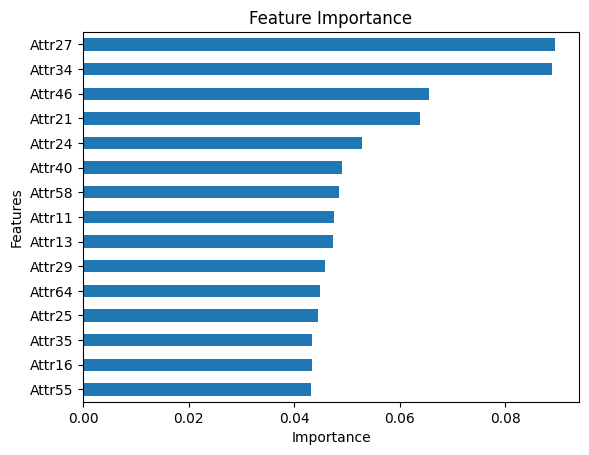

In [ ]:
importances = best_model_boost.named_steps["gradientboostingclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp.tail(15).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

<h1 style="color:darkblue";> The Correlation Matrix</h2>

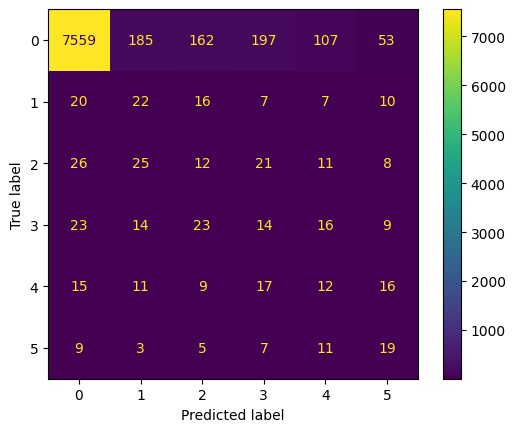

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_boost,X_test,y_test);

<h1 style="color:darkblue";>XGBOOST</h1>

In [61]:
#Classifier for XGBOOST
classifier_xgb = make_pipeline(
    XGBClassifier(random_state=42, eval_metric="mlogloss")
 )

# fitting XGBoost on all oversampled training features to rank feature importance
classifier_xgb.fit(X_train_over, y_train_over)

xgb_importances = classifier_xgb.named_steps["xgbclassifier"].feature_importances_
xgb_feature_ranking = pd.Series(xgb_importances, index=X_train_over.columns).sort_values(ascending=False)
top_20_features_xgb = xgb_feature_ranking.head(20).index.tolist()

print("Top 20 XGBoost features:")
print(top_20_features_xgb)

# reducing the data to the 20 most important features
X_train_xgb = X_train_over[top_20_features_xgb]
X_test_xgb = X_test[top_20_features_xgb]

cross_val_scores_dt = cross_val_score(
    classifier_xgb, X_train_xgb, y_train_over, cv=5, scoring="roc_auc_ovr", n_jobs=-1
 )

#hyperparameter Tuning
params_xgb = {
    "xgbclassifier__n_estimators": [100],
    "xgbclassifier__learning_rate": [0.01, 0.05, 0.1],
    "xgbclassifier__max_depth": range(3, 8),
    "xgbclassifier__reg_alpha": [0, 0.1]
}
params_xgb


#GridSearchCV
model_xgb = GridSearchCV(
    classifier_xgb,
    param_grid=params_xgb,
    cv=5,
    scoring="roc_auc_ovr",
    n_jobs=-1,
    verbose=1
)
model_xgb.fit(X_train_xgb, y_train_over)

Top 20 XGBoost features:
['Attr11', 'Attr27', 'Attr34', 'Attr26', 'Attr6', 'Attr39', 'Attr7', 'Attr22', 'Attr4', 'Attr21', 'Attr13', 'Attr42', 'Attr48', 'Attr30', 'Attr35', 'Attr25', 'Attr59', 'Attr24', 'Attr43', 'Attr38']
Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('xgbclassifier',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='mlogloss',
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      grow_policy=None,
                                                      importanc...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
                         'xgbclassifier__max_depth': range(3, 8),
                         'xgbclassifier__n_estimators': [100],
                         'xgbclassifier__reg_alpha': [0, 0.1]},
             scoring='roc_auc_ovr', verbose=1)

In [62]:
results_xgb = model_xgb.cv_results_
cv_results_xgb = pd.DataFrame(results_xgb)
cv_results_xgb.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_xgbclassifier__learning_rate,param_xgbclassifier__max_depth,param_xgbclassifier__n_estimators,param_xgbclassifier__reg_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,17.189778,0.349414,0.683405,0.182004,0.01,3,100,0.0,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.778773,0.777528,0.778498,0.780037,0.779861,0.778939,0.000924,29
1,17.597477,0.200430,0.611120,0.098875,0.01,3,100,0.1,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.778689,0.777415,0.778339,0.780172,0.780068,0.778937,0.001052,30
2,20.416689,0.680622,0.699290,0.009452,0.01,4,100,0.0,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.830910,0.828212,0.832158,0.833572,0.834096,0.831789,0.002107,27
3,20.841157,0.566403,0.767305,0.099689,0.01,4,100,0.1,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.830878,0.827983,0.832095,0.833420,0.833842,0.831644,0.002106,28
4,24.314116,0.493188,1.137010,0.188509,0.01,5,100,0.0,"{'xgbclassifier__learning_rate': 0.01, 'xgbcla...",0.882237,0.880934,0.889553,0.885490,0.887591,0.885161,0.003216,23


In [63]:
best_params_xgb = model_xgb.best_params_
best_score_xgb = model_xgb.best_score_
best_model_xgb = model_xgb.best_estimator_


print("Best Model:", best_model_xgb)
print("Best params:", best_params_xgb)
print("Best Score:", best_score_xgb)

Best Model: Pipeline(steps=[('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints

<h2 style="color:darkblue";>The Correlation Matrix</h2>

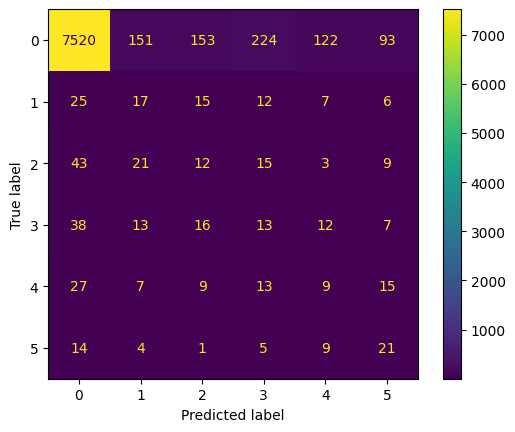

In [64]:
ConfusionMatrixDisplay.from_estimator(model_xgb, X_test_xgb, y_test);

<h2 style="color:darkblue";>The Classification Report</h2>

In [65]:
report_xgb = classification_report(y_test, model_xgb.predict(X_test_xgb) )
print(report_xgb)

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      8263
           1       0.08      0.21      0.12        82
           2       0.06      0.12      0.08       103
           3       0.05      0.13      0.07        99
           4       0.06      0.11      0.07        80
           5       0.14      0.39      0.20        54

    accuracy                           0.87      8681
   macro avg       0.23      0.31      0.25      8681
weighted avg       0.94      0.87      0.90      8681



<h2 style="color:darkblue";>Feature Importance</h2>

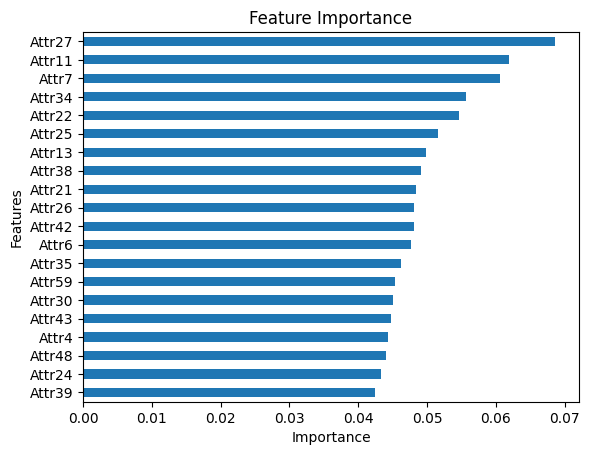

In [66]:
importances = best_model_xgb.named_steps["xgbclassifier"].feature_importances_
feat_imp = pd.Series(importances, index=top_20_features_xgb).sort_values()

feat_imp = pd.Series(importances, index=top_20_features_xgb).sort_values()

feat_imp.tail(20).plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features");

<h2 style="color:darkblue";>Saving Models</h2>

In [67]:
os.makedirs("models", exist_ok=True)

# Saving all the models
with open("models/model_rf.pkl", "wb") as f:
    pickle.dump(model_rf.best_estimator_, f)

with open("models/model_boost.pkl", "wb") as f:
    pickle.dump(model_boost.best_estimator_, f)

with open("models/model_xgb.pkl", "wb") as f:
    pickle.dump(model_xgb.best_estimator_, f)

<h2 style="color:darkblue";> Evaluating All Models</h2>

In [68]:
models = {
    "Random Forest": model_rf,
    "Gradient Boosting": model_boost,
    "XGBoost": model_xgb
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_xgb if name == "XGBoost" else X_test)
    y_prob = model.predict_proba(X_test_xgb if name == "XGBoost" else X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted"),
        "ROC-AUC (OvR)": roc_auc_score(y_test, y_prob, multi_class="ovr"),
        "Best CV Score": model.best_score_
    })

all_model_evaluation_df = pd.DataFrame(results).set_index("Model").round(4)
all_model_evaluation_df

,Accuracy,F1 (weighted),ROC-AUC (OvR),Best CV Score
Model,,,,
XGBoost,0.8746,0.9034,0.8504,0.9989
